# Análisis de residuos del modelo XGBoost

Diagnóstico de dónde se equivoca el modelo de validación (`xgboost_v1.pkl`, entrenado solo con 2023) al predecir 2024. Objetivo: identificar **sesgos sistemáticos** y patrones para defender en la presentación y para guiar V2.

Secciones:
- §1. Carga de modelo y test set 2024
- §2. Distribución global de residuos
- §3. Sesgo por hora del día
- §4. Sesgo por tipo de día
- §5. Top 20 estaciones con peor MAE absoluto
- §6. Peor error relativo (MAPE) filtrando triviales
- §7. Hubs en hora punta: ¿infraestima?
- §8. Conclusiones para defensa y V2

## 0. Setup

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (12, 5)

RAIZ = Path.cwd()
if RAIZ.name == 'notebooks':
    RAIZ = RAIZ.parent
RUTA_PARQUET = RAIZ / 'data' / 'processed' / 'numbat_long.parquet'
RUTA_MODELO = RAIZ / 'models' / 'xgboost_v1.pkl'
print(f'Parquet: {RUTA_PARQUET.exists()}')
print(f'Modelo:  {RUTA_MODELO.exists()}')

Parquet: True
Modelo:  True


## 1. Cargar modelo y test set 2024

In [2]:
blob = joblib.load(RUTA_MODELO)
modelo = blob['model']
FEATURES = blob['features']
DAY_TYPES = blob['day_type_categories']
print(f'Modelo entrenado en año {blob["trained_on_year"]}, evaluado en {blob["evaluated_on_year"]}')
print(f'Features: {FEATURES}')
print(f'Target transform: {blob["target_transform"]}')

Modelo entrenado en año 2023, evaluado en 2024
Features: ['NLC', 'day_type', 'hour', 'num_lines', 'num_modes', 'tiene_modo_tfl_explicito', 'InnerFareZone', 'OuterFareZone', 'Latitude', 'Longitude', 'is_peak', 'is_night']
Target transform: log1p


In [3]:
df = pd.read_parquet(RUTA_PARQUET)
# Replicar la preparacion de features que hace entrenamiento.py
df['tiene_modo_tfl_explicito'] = (df['num_modes'] > 0).astype(np.int8)
df['is_peak'] = df['is_peak'].astype(np.int8)
df['is_night'] = df['is_night'].astype(np.int8)
df['NLC'] = df['NLC'].astype('category')
df['day_type'] = pd.Categorical(df['day_type'], categories=DAY_TYPES)

df_test = df[df['year'] == 2024].copy()
print(f'Test 2024: {len(df_test):,} filas')

Test 2024: 207,360 filas


In [4]:
# Predicciones en escala original
y_real = df_test['passengers'].values
y_pred_log = modelo.predict(df_test[FEATURES])
y_pred = np.clip(np.expm1(y_pred_log), 0, None)

df_test['y_pred'] = y_pred
df_test['residuo'] = y_real - y_pred                       # positivo -> infrapredice
df_test['residuo_abs'] = np.abs(df_test['residuo'])
df_test['residuo_rel'] = np.where(y_real > 1, df_test['residuo'] / y_real, np.nan)
print('Residuos calculados.')

Residuos calculados.


## 2. Distribución global de residuos

Estadisticas del residuo (real - pred):
count    207360.00
mean          3.90
std          41.77
min       -1152.98
25%          -3.31
50%           0.00
75%           5.33
max        1612.16
Name: residuo, dtype: float64

Mediana residuo: 0.00  (sesgo: positivo=infrapredice)


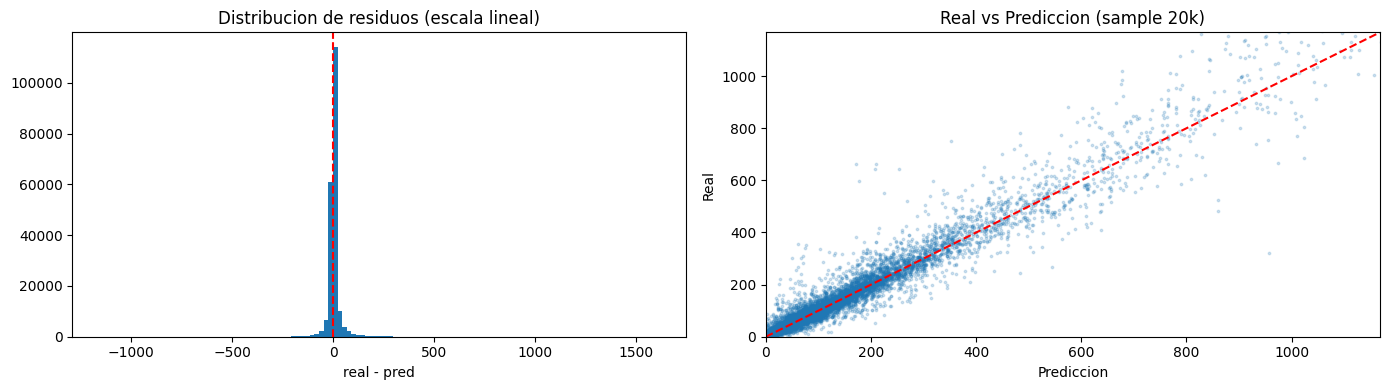

In [5]:
print('Estadisticas del residuo (real - pred):')
print(df_test['residuo'].describe().round(2))
print(f'\nMediana residuo: {df_test["residuo"].median():.2f}  (sesgo: positivo=infrapredice)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_test['residuo'], bins=120)
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Distribucion de residuos (escala lineal)')
axes[0].set_xlabel('real - pred')

# Real vs Pred scatter
muestra = df_test.sample(min(20000, len(df_test)), random_state=42)
axes[1].scatter(muestra['y_pred'], muestra['passengers'], s=3, alpha=0.2)
lim = muestra['passengers'].quantile(0.99)
axes[1].plot([0, lim], [0, lim], 'r--')
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel('Prediccion'); axes[1].set_ylabel('Real')
axes[1].set_title('Real vs Prediccion (sample 20k)')
plt.tight_layout(); plt.show()

## 3. Sesgo por hora del día

        mae  sesgo_medio  real_medio
hour                                
0      8.21         4.52       18.10
1      1.45         0.55        4.16
2      0.96         0.83        2.63
3      0.77         0.59        2.08
4      0.85         0.13        1.38
5     11.24         4.11       22.44
6     18.54         5.29       75.35
7     25.74         5.93      138.46
8     25.38        10.92      173.60
9     19.63         7.50      137.17
10    15.29         3.78      118.04
11    15.27         3.59      124.69
12    15.55         4.80      135.78
13    15.39         3.65      138.68
14    16.01         2.82      143.06
15    21.92         6.04      169.50
16    26.96         3.94      205.51
17    27.79         7.40      234.55
18    27.19         4.30      198.32
19    17.73         2.93      131.12
20    13.22         3.24       93.46
21    11.40         2.15       80.44
22    12.27         1.28       76.08
23    12.22         3.19       50.65


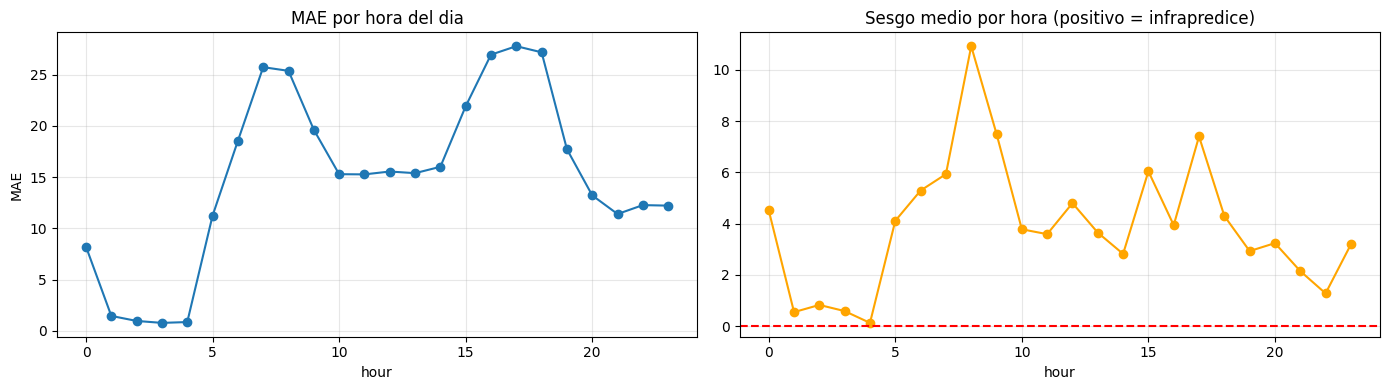

In [6]:
por_hora = df_test.groupby('hour').agg(
    mae=('residuo_abs', 'mean'),
    sesgo_medio=('residuo', 'mean'),
    real_medio=('passengers', 'mean'),
).round(2)
print(por_hora)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_hora['mae'].plot(ax=axes[0], marker='o')
axes[0].set_title('MAE por hora del dia')
axes[0].set_ylabel('MAE'); axes[0].grid(alpha=0.3)
por_hora['sesgo_medio'].plot(ax=axes[1], marker='o', color='orange')
axes[1].axhline(0, color='red', ls='--')
axes[1].set_title('Sesgo medio por hora (positivo = infrapredice)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Sesgo por tipo de día

In [7]:
por_dia = df_test.groupby('day_type', observed=True).agg(
    mae=('residuo_abs', 'mean'),
    sesgo_medio=('residuo', 'mean'),
    real_medio=('passengers', 'mean'),
).round(2).reindex(DAY_TYPES)
print(por_dia)

            mae  sesgo_medio  real_medio
day_type                                
MON       16.62         6.98      106.20
TWT       17.80         6.09      124.64
FRI       15.06         3.18      114.48
SAT       15.19         2.61      102.17
SUN       10.53         0.62       68.19


## 5. Top 20 estaciones con peor MAE absoluto

Donde el modelo se equivoca más en términos absolutos. Esperable: estaciones con muchos pasajeros (Waterloo, King's Cross), porque el error escala con el volumen.

In [8]:
por_est = df_test.groupby('UniqueStationName', observed=True).agg(
    mae=('residuo_abs', 'mean'),
    sesgo_medio=('residuo', 'mean'),
    real_medio=('passengers', 'mean'),
    n=('passengers', 'size'),
).round(2)
top_mae = por_est.sort_values('mae', ascending=False).head(20)
print('Top 20 estaciones por MAE absoluto:')
print(top_mae)

Top 20 estaciones por MAE absoluto:
                             mae  sesgo_medio  real_medio    n
UniqueStationName                                             
Liverpool Street LU       218.50       214.33      943.28  480
Waterloo LU               174.97       136.84     1104.49  480
Wimbledon                 120.53      -113.50      308.67  480
King's Cross St. Pancras   97.66        39.79     1151.26  480
Paddington TfL             94.07        56.93      811.11  480
Tottenham Court Road       93.45       -18.79      881.43  480
Victoria LU                92.69        38.96      914.58  480
London Bridge LU           91.56        24.99      873.98  480
Liverpool Street NR        82.25        42.17      463.72  480
Stratford                  80.55       -16.17      830.23  480
Watford Junction           78.73        78.68      112.57  480
South Kensington           69.08        41.95      442.44  480
Oxford Circus              68.12       -15.05      723.57  480
Bank and Monument  

## 6. Peor MAPE filtrando casos triviales

MAPE entre filas con `real > 5` para evitar la explosión de errores relativos en valores diminutos del modelo NUMBAT.

In [9]:
df_mape = df_test[df_test['passengers'] > 5].copy()
df_mape['ape'] = np.abs(df_mape['residuo']) / df_mape['passengers']
mape_global = df_mape['ape'].mean()
mape_diurno = df_mape[df_mape['is_night']==0]['ape'].mean()
mape_nocturno = df_mape[df_mape['is_night']==1]['ape'].mean() if (df_mape['is_night']==1).any() else None
print(f'MAPE corregido (real > 5):')
print(f'  Global:    {mape_global*100:.2f}%  (n = {len(df_mape):,})')
print(f'  Diurno:    {mape_diurno*100:.2f}%')
print(f'  Nocturno:  {mape_nocturno*100:.2f}%' if mape_nocturno is not None else '  Nocturno:  N/A')

# Por estacion
mape_por_est = df_mape.groupby('UniqueStationName', observed=True)['ape'].mean().sort_values(ascending=False).head(15)
print(f'\nTop 15 estaciones por MAPE (peor error relativo):')
print((mape_por_est * 100).round(1).to_string())

MAPE corregido (real > 5):
  Global:    19.73%  (n = 160,420)
  Diurno:    18.68%
  Nocturno:  47.94%

Top 15 estaciones por MAPE (peor error relativo):
UniqueStationName
Bruce Grove         133.4
Hackney Downs        82.5
Paddington NR        81.1
Watford Junction     66.9
Kew Gardens          63.3
Kentish Town         59.8
Wimbledon            57.9
Limehouse DLR        54.7
Peckham Rye          50.2
Norwood Jn           49.2
Denmark Hill         46.3
New Cross Gate       45.1
Maidenhead           44.3
Woolwich Arsenal     42.9
Tufnell Park         41.4


## 7. Hubs en hora punta: ¿infraestima el modelo?

In [10]:
hubs = ['Waterloo LU', "King's Cross St. Pancras", 'Liverpool Street LU',
        'Victoria LU', 'London Bridge LU', 'Oxford Circus',
        'Bank and Monument', 'Bond Street', 'Stratford', 'Paddington TfL']
hubs_pico = df_test[(df_test['UniqueStationName'].isin(hubs)) & (df_test['is_peak']==1)]
print(f'Predicciones en hubs durante hora punta: {len(hubs_pico):,} filas\n')

tabla = hubs_pico.groupby('UniqueStationName', observed=True).agg(
    real_medio=('passengers', 'mean'),
    pred_medio=('y_pred', 'mean'),
    sesgo_medio=('residuo', 'mean'),
    mae=('residuo_abs', 'mean'),
).round(1).sort_values('real_medio', ascending=False)
print(tabla)
print(f'\nMedia del sesgo en hubs durante pico: {hubs_pico["residuo"].mean():.1f}')
print('  Positivo = el modelo infrapredice los picos de los hubs.')

Predicciones en hubs durante hora punta: 600 filas

                          real_medio   pred_medio  sesgo_medio    mae
UniqueStationName                                                    
Waterloo LU                   2873.9  2474.699951        399.2  528.4
Liverpool Street LU           2238.4  1682.099976        556.3  563.1
King's Cross St. Pancras      1976.9  1900.699951         76.3  182.5
Victoria LU                   1907.9  1771.500000        136.4  203.3
London Bridge LU              1728.0  1593.300049        134.7  193.8
Paddington TfL                1710.3  1514.000000        196.3  245.9
Stratford                     1495.8  1533.599976        -37.8  107.8
Bank and Monument             1439.1  1346.599976         92.4  190.5
Oxford Circus                 1236.2  1303.300049        -67.1  119.2
Bond Street                   1110.5  1172.099976        -61.6  132.3

Media del sesgo en hubs durante pico: 142.5
  Positivo = el modelo infrapredice los picos de los hubs.


## 8. Conclusiones — rellenar tras ejecutar

**8.1. ¿Sesgo sistemático global?**
- Mediana de residuo: ...
- Forma de la distribución (simétrica, sesgada, multimodal): ...

**8.2. ¿Dónde se equivoca más?**
- Peor MAE absoluto: hubs en hora punta (...)
- Peor MAPE relativo: ...
- Horas problemáticas: ...

**8.3. Hipótesis para V2**
- ...

**8.4. Frase para la defensa**
*'El modelo tiene un sesgo de infrapredicción de unos X pasajeros en hubs durante hora punta (Waterloo, King's Cross). Esto es esperable porque los valores extremos son raros en el entrenamiento. Para mitigar este efecto en V2, podríamos entrenar con `objective=reg:tweedie` o usar quantile regression.'*

**8.5. MAPE corregido del §6:** ...% (con filtro `real > 5`). Reemplaza al MAPE inflado del JSON original.